<a href="https://colab.research.google.com/github/truth-breaker/DATA-SCIENCE/blob/main/Statistical_Analysis_of_Fertilizer_Effects_on_Avocado_Tree_Growth_Duration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
#Objective: To test if avocado trees that receive fertilizer have a shorter average growth duration compared to those that do not.
# Using statistical methods such as Permutation Test, Bootstrapping and confidence intervals


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
avocado_info = pd.read_csv("avocado_info.csv")

In [33]:
avocado_info.head()

,Growth Duration,Fertilizer
0,98,True
1,108,False
2,129,False
3,116,False
4,111,False


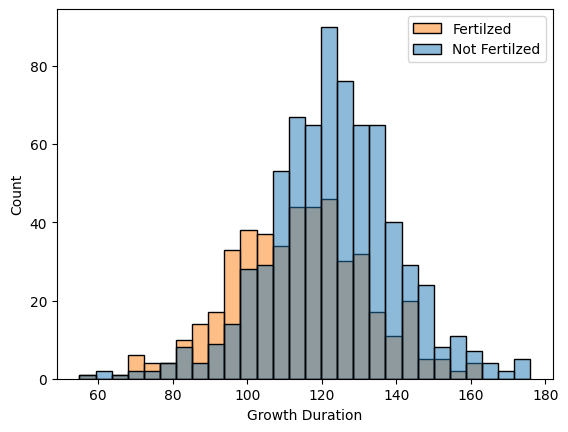

In [34]:
#is there an association btwn duration of growth and whether fertilzer was used
sns.histplot(data = avocado_info, x = 'Growth Duration', hue = 'Fertilizer')
plt.legend(['Fertilzed', 'Not Fertilzed'])

In [35]:
#Splitting into groups
fertilized = avocado_info.loc[avocado_info['Fertilizer']== True]
unfertilized = avocado_info.loc[avocado_info['Fertilizer']== False]

In [36]:
# Test Stats, Average growth duration among avoc trees that recieved fertilzer minus Avg growth duration among avoc tree that did not
'''
This calculates the observed difference in average growth duration:

mean(fertilized)−mean(unfertilized)

If this value is negative, it means fertilized trees grew faster (shorter duration).
'''
observed_test_stat = np.mean(fertilized["Growth Duration"]) - np.mean(unfertilized['Growth Duration'])
observed_test_stat

np.float64(-9.266142572024918)

In [37]:
avocado_info['Growth Duration'].sample(frac=1)

,Growth Duration
247,90
854,103
725,104
285,116
729,122
...,...
1079,118
225,101
194,120
780,75


In [38]:
avocado_info['Growth Duration'].sample(frac=1).reset_index()

,index,Growth Duration
0,61,98
1,282,123
2,154,107
3,727,122
4,518,96
...,...,...
1169,616,117
1170,719,127
1171,712,144
1172,1156,127


In [39]:
avocado_info['Growth Duration'].sample(frac =1).reset_index(drop = True)

,Growth Duration
0,138
1,111
2,122
3,121
4,134
...,...
1169,112
1170,144
1171,132
1172,155


In [ ]:
'''
In real life, we want to compare fertilized vs. unfertilized.

In the permutation test, we pretend fertilizer makes no difference by shuffling the numbers and reassigning them.

Then we re-calculate the difference in means between the two groups in this pretend world.

If our real difference is much bigger/smaller than most pretend differences, then fertilizer probably does matter.

df makes a new mini-table (a DataFrame).

Column 1: the shuffled growth durations (perm_info).

Column 2: the original fertilizer labels (True/False).

So now each shuffled number is randomly paired with a fertilizer label (like “True” or “False”).

- This is our “pretend world” if fertilizer doesn’t matter — because the numbers were just assigned randomly.
'''

In [40]:
def perm(data):
  return data.sample(frac =1).reset_index(drop=True)

In [56]:
sim_test_stat = np.array([]) # collect all test statistic generated during perm test
reps = 10000 # number of repetitions that will occur in the permutation test

for i in range(reps):
  #calls your perm() function to shuffle the Growth Duration column and returns the shuffled Series (same values but in random order).
  perm_info = perm(avocado_info["Growth Duration"])
  df = pd.DataFrame({'Permuted Duration':perm_info,'Fertilizer':avocado_info['Fertilizer']})
  fertilized = df.loc[df['Fertilizer']== True, 'Permuted Duration']
  not_fertilized = df.loc[df["Fertilizer"]== False, 'Permuted Duration']
  stat = np.mean(fertilized)-np.mean(not_fertilized)
  sim_test_stat = np.append(sim_test_stat, stat)

**bold text**

In [42]:
#sim_test_stat = a list of pretend outcomes under the “fertilizer doesn’t matter” world.
sim_test_stat

array([ 0.23145787,  0.42105215,  0.56771943, ..., -1.14578363,
       -0.97049835, -0.70935905])

In [43]:
#pvalue-A measure of the statisical evidenece againist null hypothesis (probablilty of a observed or more exterme result assuming that null hyp is true)- determine the likelihood that an observed outcome is the result of chance

In [44]:
#In this test the p-value will be the proportion of simulated values of the test stat that were less than or equal to the observed value of the test stat
# To compute this proportion- divide the number of simulated values that satisfied this conditon over the # of simulated values)
# To count the # that satify the condition then use the count non-zero method from numpy libaray
p_value = np.count_nonzero(sim_test_stat <= observed_test_stat)/reps

In [45]:
# Reject the null hyp. Since p-value is lower than the p-value cutof of 5%
# Conclude that there is a statisically significant the avg growing time among avocado trees that
# recieved fertilzer and the avg growing time among avocado
p_value

0.0

**BootStrapping**

In [46]:
fertilized = avocado_info.loc[avocado_info['Fertilizer']==True, 'Growth Duration']
unfertilized = avocado_info.loc[avocado_info['Fertilizer']==False, 'Growth Duration']

In [47]:
# a new sample of growth duration of fertilzed avoc
np.random.choice(fertilized, size = len(fertilized))

array([ 98,  81, 134, 144, 100, 120, 102,  87, 145,  91,  99, 104, 120,
       105, 119,  91,  91, 123, 125, 117, 103, 107, 129, 129, 108,  96,
       142, 110, 127, 122, 103, 122, 115, 123, 117, 104, 156, 121, 126,
       125, 102,  88, 131, 113, 129, 105, 101, 113, 109, 120,  83, 118,
       131, 115, 101, 131, 125, 133, 127, 133, 130, 122,  90, 128,  97,
       114, 143, 132, 117, 100, 118, 122,  98, 144, 124,  58, 131, 154,
       144, 100, 136, 110, 119,  94, 115,  87, 119, 118,  92, 100, 107,
       139, 113, 126,  92,  80,  97,  77,  96, 105, 122, 104, 144, 144,
       115, 115, 119, 160, 109, 130, 106,  93, 131,  94,  91, 111, 100,
       133, 128, 120, 102, 126, 101, 119, 128, 119, 114, 108, 136, 117,
       102, 114,  99,  98, 129, 131,  88, 109, 125, 119, 145, 100, 116,
       122, 124, 144, 100,  86, 129, 144, 108, 144,  97,  97, 115, 101,
       123, 126, 115, 103, 114, 115, 125,  91, 120, 109, 117, 115, 100,
       127, 100, 108,  88, 153, 127, 131,  82, 114, 119, 114, 12

In [48]:
np.random.choice(unfertilized, size = len(unfertilized))

array([105, 123, 141, 134, 121, 174, 129, 155, 122, 144, 111, 128, 127,
        96, 137, 127, 114,  97, 115, 112, 138, 127,  93, 106,  72, 114,
       113, 120, 113, 129, 173, 123, 110,  55, 123, 139, 127, 119, 107,
       119, 143, 113, 137, 103, 128, 111, 125, 131, 140, 112, 147, 135,
       147, 125, 111, 128, 126, 100,  91, 116, 150, 114,  85, 131, 121,
       114, 154, 112, 174, 167, 125, 116, 110, 124, 163, 133, 131, 125,
       137, 105, 121,  55, 101,  87, 109, 113, 113, 136, 128, 120,  85,
       117, 142, 131, 110, 128, 112, 134, 132, 163, 129, 114, 125, 122,
       116, 133, 128, 136, 134, 128, 146, 125, 100, 117, 120, 137, 119,
       131, 128, 116, 110, 124, 125, 112, 106, 113, 118, 117,  91, 125,
       132, 141, 110, 115, 120, 126,  84, 113, 124, 157, 106, 121, 135,
       132, 115, 116, 114, 104, 152, 144, 140, 128,  84, 103, 125, 130,
       127, 115, 125, 123,  72, 118, 118, 124, 111,  72, 122, 130, 153,
       128, 140, 136, 127, 132, 117, 152, 167, 123, 107, 149, 13

In [49]:
def resample (orig_sample):
  return np.random.choice(orig_sample, size = len(orig_sample))

In [50]:
#Bootstrapping used to get a better sense of which results are likely and which are rare
def bootstrap(orig_sample,reps):
  means = np.array([])
  for i in range (reps):
      new_sample = resample(orig_sample)
      new_mean = np.mean(new_sample)
      means = np.append(means, new_mean)

  return means

In [51]:
fertilized_means = bootstrap(fertilized,10000)
unfertilized_means = bootstrap(unfertilized, 10000)
estimates = fertilized_means - unfertilized_means

In [52]:
estimates

array([ -8.14759358,  -8.97305483, -11.70824383, ..., -10.82707619,
        -8.37404208,  -7.50411201])

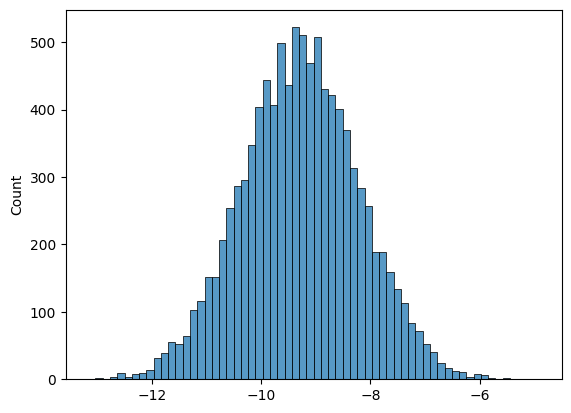

In [53]:
sns.histplot(estimates)
plt.show()

In [54]:
#construct a  95% confidence interval
#This confidence interval states that 95% confidence that the populaon mean differnce in growth
#Duration btwn avocado tree that were fertilzwed and those were not is btwn -11.34 and -7.13
'''
The values -11 and -7 refer to the endpoints of a 95% confidence interval
for the difference in average growth durations between fertilized
and non-fertilized avocado trees. This interval suggests that, with 95% confidence,
the true difference in growth durations lies between -11.34 and -7.19 days.
Negative values indicate that, on average, fertilized trees grow faster than non-fertilized ones.
'''
(np.percentile(estimates,2.5),np.percentile(estimates,97.5))

(np.float64(-11.373322897146428), np.float64(-7.173247634718225))

In [55]:
'''
Both the permutation test (p-value small) and the bootstrap CI
(all negative values) strongly support the alternative hypothesis.
That means fertilizer significantly reduces growth duration for avocado trees.
'''

'\nBoth the permutation test (p-value small) and the bootstrap CI \n(all negative values) strongly support the alternative hypothesis. \nThat means fertilizer significantly reduces growth duration for avocado trees.\n'